In [1]:
!pip install transformers datasets

In [2]:
import re
import random
from datasets import load_dataset, Dataset, DatasetDict
from transformers import T5Tokenizer,Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback
import pandas as pd
import itertools
from typing import List, Dict, Optional
import nltk
from nltk.tokenize import sent_tokenize
import requests
import json
import numpy as np
import torch
from datasets import load_from_disk
from transformers import (
    T5Tokenizer,
    T5Config,
    T5ForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
import torch.nn as nn
from transformers.modeling_outputs import BaseModelOutput

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def create_unpunctuated_text(text: str) -> str:
    """Remove punctuation and capitalization from text"""
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def add_extra_spaces(text: str) -> str:
    """Add extra spaces randomly"""
    words = text.split()
    result = []
    for word in words:
        result.append(word)
        if random.random() < 0.3:  # 30% chance to add extra space
            result.append(' ')
    return ' '.join(result)

def remove_some_spaces( text: str) -> str:
    """Remove some spaces randomly"""
    words = text.split()
    result = []
    for i, word in enumerate(words):
        result.append(word)
        if i < len(words) - 1 and random.random() < 0.2:  # 20% chance to remove space
            continue
        else:
            result.append(' ')
    return ''.join(result).strip()

def mix_case_randomly(text: str) -> str:
    """Randomly mix uppercase and lowercase"""
    return ''.join(c.upper() if random.random() < 0.1 else c.lower() for c in text)


def load_wikipedia_dataset(language: str = "en", max_samples: Optional[int] = 10000):
    nltk.download('punkt')
    nltk.download('punkt_tab')
    try:
        wiki_dataset = load_dataset("wikimedia/wikipedia", f"20231101.{language}", split="train", streaming=True)

        samples = []
        count = 0

        for example in wiki_dataset:
            if max_samples and count >= max_samples:
                break

            text = example['text']
            sentences = sent_tokenize(text)

            for sentence in sentences:
                if len(sentence.split()) > 5:
                    # Apply transformations sequentially
                    input_text = create_unpunctuated_text(sentence)
                    input_text = add_extra_spaces(input_text)
                    input_text = remove_some_spaces(input_text)
                    input_text = mix_case_randomly(input_text)

                    if input_text.strip() and input_text != sentence:
                        samples.append({
                            "input_text": f"normalize: {input_text}",
                            "target_text": sentence
                        })
                        count += 1

            if count % 1000 == 0:
                print(f"Processed {count} samples...")

        dataset = Dataset.from_list(samples)
        print(f" Created Wikipedia dataset with {len(dataset)} samples")
        return dataset

    except Exception as e:
        print(f"Error loading Wikipedia dataset: {e}")
        return None


wiki_dataset = load_wikipedia_dataset(max_samples=100000)
train_test_split = wiki_dataset.train_test_split(test_size=0.2, seed=42)

print(f"\nFinal dataset statistics:")
print(f"Training samples: {len(train_test_split['train'])}")
print(f"Validation samples: {len(train_test_split['test'])}")

# Save datasets
train_test_split['train'].save_to_disk("./large_text_normalization_train")
train_test_split['test'].save_to_disk("./large_text_normalization_val")

# Show sample
print("\nSample from dataset:")
for i in range(3):
    sample = train_test_split['train'][i]
    print(f"Input:  {sample['input_text']}")
    print(f"Output: {sample['target_text']}")
    print()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Processed 39000 samples...
 Created Wikipedia dataset with 100034 samples

Final dataset statistics:
Training samples: 80027
Validation samples: 20007


Saving the dataset (0/1 shards):   0%|          | 0/80027 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/20007 [00:00<?, ? examples/s]


Sample from dataset:
Input:  normalize: most oftheislands remaIned lArgeLy uncontrOlleD anD undefended making them a potential opportunityfoR noRthWesterneuropEan coUntries thatwantedto breaksPains monopoLy on colonizingthe new world
Output: Most of the islands remained largely uncontrolled and undefended, making them a potential opportunity for northwestern European countries that wanted to break Spain's monopoly on colonizing the New World.

Input:  normalize: he Works hard to MaKe an antIplague Serum but as the epidemIc continUes He shows increaSinGsigns Ofwear and tear
Output: He works hard to make an antiplague serum, but as the epidemic continues, he shows increasing signs of wear and tear.

Input:  normalize: ancestryand immigration at the 2021 Census the mostcOmmoNly nominated ancestries wereoveRseaSborN adelaideaNs composeD 313of thE total population aT the 2021 census
Output: Ancestry and immigration 

At the 2021 census, the most commonly nominated ancestries were: 

Overse

In [5]:

train_dataset = load_from_disk("/content/large_text_normalization_train")
test_dataset  = load_from_disk("/content/large_text_normalization_val")


model_name = "t5-small"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)


def preprocess(examples):
    inputs = examples["input_text"]
    targets = examples["target_text"]

    model_inputs = tokenizer(inputs,
                             truncation=True, padding="max_length",max_length=256)

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets,
                           truncation=True, padding="max_length",max_length=256)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_dataset = train_dataset.map(preprocess, batched=True)
test_dataset  = test_dataset.map(preprocess, batched=True)


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/80027 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/20007 [00:00<?, ? examples/s]

In [7]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

In [ ]:
# Adjust sample sizes based on available compute
small_train = train_dataset.shuffle(seed=42).select(range(10000))
small_val = test_dataset.shuffle(seed=42).select(range(1000))

# Define Hyperparameter Grid
learning_rates = [5e-5, 1e-4, 3e-4]
weight_decays = [0.01, 0.05]
label_smooths = [0.0, 0.1]

results = []

# Run Each Combination

for lr, wd, ls in itertools.product(learning_rates, weight_decays, label_smooths):
    print(f"\n Training with lr={lr}, weight_decay={wd}, label_smoothing={ls}")

    training_args = Seq2SeqTrainingArguments(
        #output_dir=f"./t5_tuning/lr{lr}_wd{wd}_ls{ls}",
        eval_strategy ="steps",
       # save_strategy="epoch",
       # save_total_limit=1,                  # Keep only last checkpoint
        learning_rate=lr,
        weight_decay=wd,
        num_train_epochs=3,                  # Slightly higher for early stopping to kick in
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        predict_with_generate=False,         # Speed up evaluation
        fp16=True,                           # Mixed precision
        label_smoothing_factor=ls,
        #load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to="none",                    # Disable external logging (wandb/tensorboard)
    )

    # Define trainer with early stopping callback
    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=small_train,
        eval_dataset=small_val,
        tokenizer=tokenizer,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  # stops after 2 evals without improvement
    )

    trainer.train()
    eval_results = trainer.evaluate()
    eval_loss = eval_results["eval_loss"]

    print(f" Finished: eval_loss = {eval_loss:.4f}")
    results.append((lr, wd, ls, eval_loss))

#Identify Best Combination

best = min(results, key=lambda x: x[3])
print("\n Best Hyperparameter Combination:")
print(f"Learning Rate: {best[0]}")
print(f"Weight Decay:  {best[1]}")
print(f"Label Smooth:  {best[2]}")
print(f"Eval Loss:     {best[3]:.4f}")



 Training with lr=5e-05, weight_decay=0.01, label_smoothing=0.0


/tmp/ipython-input-2285034813.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss
500,No log,0.246463
1000,No log,0.204140
1500,1.486400,0.188379
2000,1.486400,0.179956
2500,1.486400,0.174281
3000,0.235800,0.171468
3500,0.235800,0.169882


 Finished: eval_loss = 0.1697

 Training with lr=5e-05, weight_decay=0.01, label_smoothing=0.1


/tmp/ipython-input-2285034813.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


...

Step,Training Loss,Validation Loss
500,No log,0.141558
1000,No log,0.147163
1500,0.035900,0.146697


 Finished: eval_loss = 0.1467

 Training with lr=0.0003, weight_decay=0.05, label_smoothing=0.1


/tmp/ipython-input-2285034813.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss
500,No log,1.515545
1000,No log,1.515911
1500,1.501600,1.515067
2000,1.501600,1.513163
2500,1.501600,1.508907
3000,1.467900,1.506315
3500,1.467900,1.503088


 Finished: eval_loss = 1.5018

 Best Hyperparameter Combination:
Learning Rate: 0.0003
Weight Decay:  0.01
Label Smooth:  0.0
Eval Loss:     0.1175


In [8]:



# def compute_metrics(eval_pred):
#     predictions, labels = eval_pred

#     # Decode
#     preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
#     labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
#     refs = tokenizer.batch_decode(labels, skip_special_tokens=True)

#     # Exact string match accuracy
#     correct = sum(p.strip() == r.strip() for p, r in zip(preds, refs))
#     acc = correct / len(preds)

#     return {"accuracy": acc}

# using the hypo parameters from the best perfroming model in above step
Learning_Rate= 3e-4
Weight_Decay=  0.01
Label_Smooth=  0.0

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/t5-text-normalization/",
    eval_strategy ="steps",
    eval_steps=1000,
    save_strategy="epoch",
    learning_rate=Learning_Rate,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    label_smoothing_factor=Label_Smooth,
    weight_decay=Weight_Decay,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    logging_dir="./logs",
    logging_steps=100,
    report_to="none"
)


trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
   # compute_metrics=compute_metrics
)

trainer.train()

print("Evaluating on test set...")
results = trainer.evaluate()
print(results)


/tmp/ipython-input-3997159205.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss,Validation Loss
1000,0.200300,0.155964
2000,0.157600,0.137528
3000,0.162000,0.124922
4000,0.146500,0.116692
5000,0.155200,0.111481
6000,0.165700,0.106454
7000,0.143400,0.101676
8000,0.129100,0.099401
9000,0.135900,0.096116
10000,0.131300,0.092783


Evaluating on test set...


{'eval_loss': 0.07447931915521622, 'eval_runtime': 253.9553, 'eval_samples_per_second': 78.782, 'eval_steps_per_second': 9.848, 'epoch': 3.0}


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_hf_training_logs(trainer):
    # Convert log history to DataFrame
    logs = pd.DataFrame(trainer.state.log_history)

    # Filter only rows with loss values
    train_logs = logs[logs["loss"].notnull()]
    eval_logs = logs[logs["eval_loss"].notnull()]

    # Extract values
    train_loss = train_logs["loss"].values
    eval_loss = eval_logs["eval_loss"].values
    train_epochs = train_logs["epoch"].values
    eval_epochs = eval_logs["epoch"].values

    # Plot Training & Evaluation Loss
    plt.figure(figsize=(8, 5))
    plt.plot(train_epochs, train_loss, "bo-", label="Training Loss")
    plt.plot(eval_epochs, eval_loss, "ro-", label="Evaluation Loss")
    plt.title("Training and Evaluation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


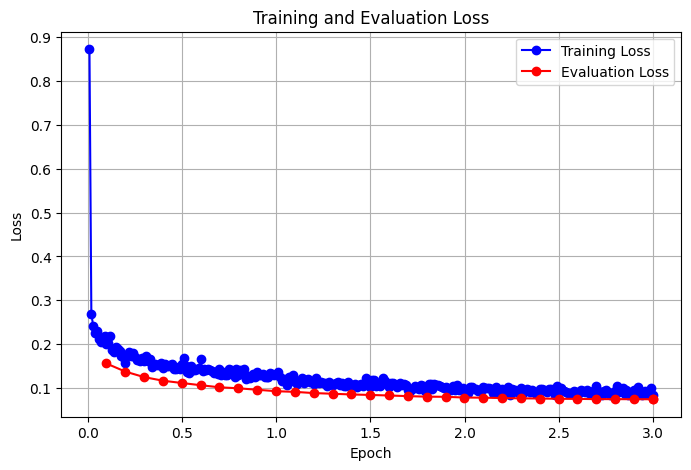

In [10]:
plot_hf_training_logs(trainer)